In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pablomgomez21/drugs-a-b-c-x-y-for-decision-trees")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\SATWIK\.cache\kagglehub\datasets\pablomgomez21\drugs-a-b-c-x-y-for-decision-trees\versions\1


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("ALL DONE")

ALL DONE


In [13]:
df = pd.read_csv(r"C:\Users\SATWIK\.cache\kagglehub\datasets\pablomgomez21\drugs-a-b-c-x-y-for-decision-trees\versions\1\drug200.csv")
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [14]:
df['target'] = df['Drug']
df


,Age,Sex,BP,Cholesterol,Na_to_K,Drug,target
0,23,F,HIGH,HIGH,25.355,drugY,drugY
1,47,M,LOW,HIGH,13.093,drugC,drugC
2,47,M,LOW,HIGH,10.114,drugC,drugC
3,28,F,NORMAL,HIGH,7.798,drugX,drugX
4,61,F,LOW,HIGH,18.043,drugY,drugY
...,...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC,drugC
196,16,M,LOW,HIGH,12.006,drugC,drugC
197,52,M,NORMAL,HIGH,9.894,drugX,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX,drugX


In [15]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [16]:
x = df.drop('Drug', axis=1)
y = df['Drug']


In [17]:
x = pd.get_dummies(df.drop('Drug', axis=1), drop_first=True)
y = df['Drug']


In [18]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)


In [19]:
model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

In [20]:
model.fit(x_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
y_pred = model.predict(x_test)


In [22]:
y_pred

array(['drugX', 'drugY', 'drugX', 'drugC', 'drugY', 'drugY', 'drugY',
       'drugX', 'drugA', 'drugX', 'drugA', 'drugX', 'drugY', 'drugA',
       'drugB', 'drugY', 'drugB', 'drugX', 'drugC', 'drugY', 'drugB',
       'drugX', 'drugX', 'drugY', 'drugY', 'drugY', 'drugC', 'drugX',
       'drugY', 'drugX', 'drugY', 'drugC', 'drugC', 'drugY', 'drugA',
       'drugY', 'drugX', 'drugA', 'drugY', 'drugA'], dtype=object)

In [23]:
acc = accuracy_score(y_test,y_pred)
acc

1.0

<Axes: >

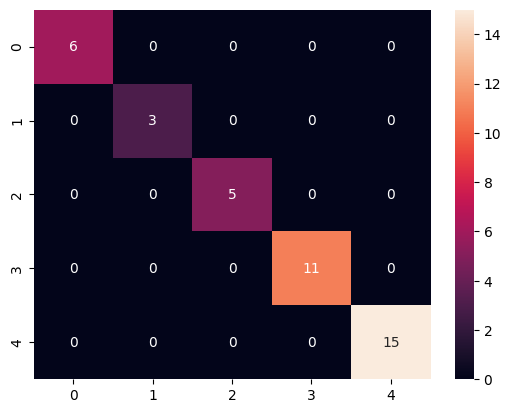

In [24]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)

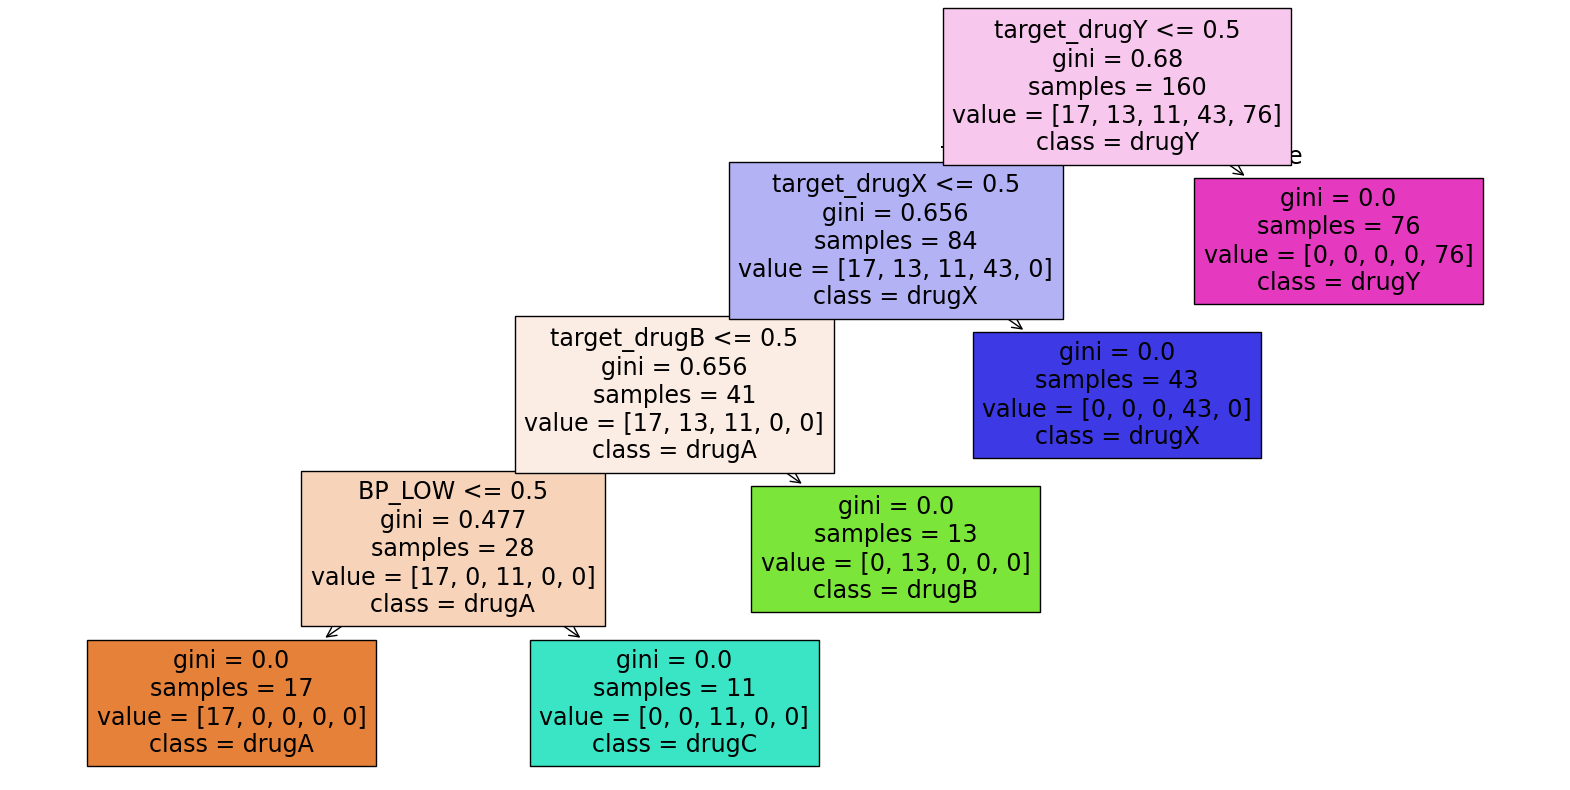

In [26]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=model.classes_,
    filled=True
)

plt.show()
